In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the cleaned dataset
df = pd.read_csv("../data/processed/customer_churn_cleaned.csv")

# Display the first five rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 21


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

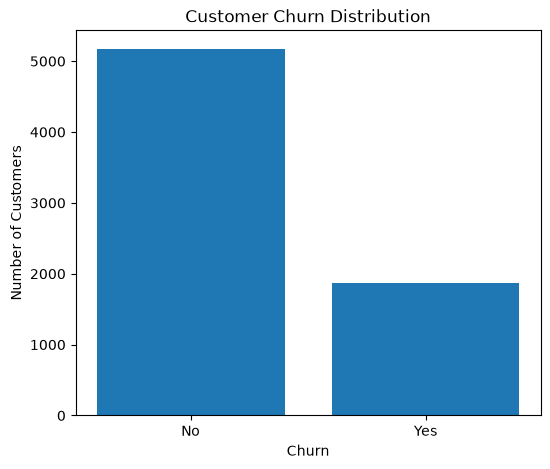

In [4]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(churn_counts.index, churn_counts.values)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [5]:
churn_percentage = (df["Churn"].value_counts(normalize=True) * 100).round(2)

print(churn_percentage)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


## Business Insight

Approximately 26% of customers have churned, while 74% remain active.

Although most customers stay with the company, the churn rate is significant enough to impact revenue and customer lifetime value.

The next analyses will identify which customer groups are most likely to churn, helping the business target retention strategies effectively.

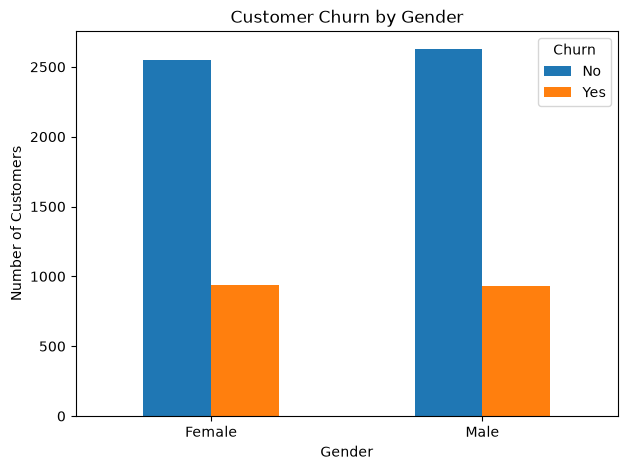

In [6]:
# Churn by Gender
gender_churn = pd.crosstab(df["gender"], df["Churn"])

gender_churn.plot(kind="bar", figsize=(7,5))

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

## Business Insight

The visualization compares churn rates between male and female customers.

If both genders show similar churn patterns, gender is not a major factor influencing customer churn. The company should instead focus on factors such as contract type, tenure, payment method, and monthly charges.

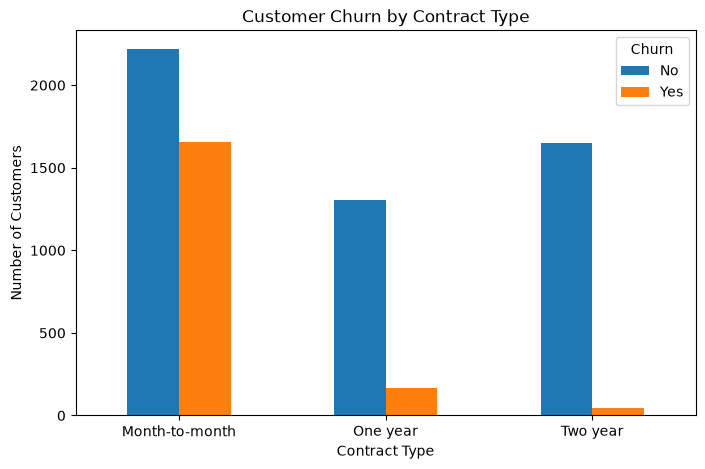

In [7]:
# Churn by Contract Type
contract_churn = pd.crosstab(df["Contract"], df["Churn"])

contract_churn.plot(kind="bar", figsize=(8,5))

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

## Business Insight

Customers with month-to-month contracts are more likely to churn than customers with one-year or two-year contracts.

Long-term contracts improve customer retention because customers are committed for a longer period.

In [8]:
plt.savefig("../images/chart_name.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

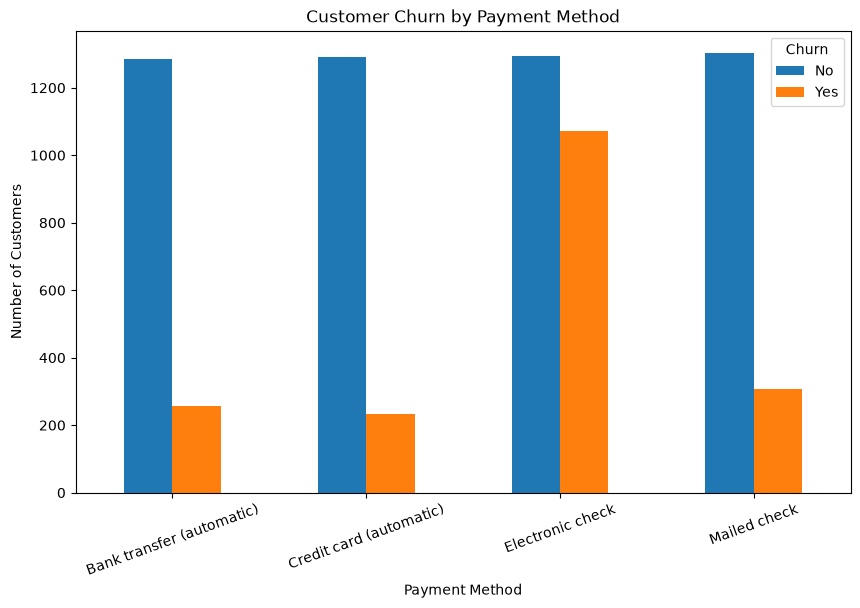

In [9]:
payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"])

payment_churn.plot(kind="bar", figsize=(10,6))

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.savefig("../images/churn_by_payment_method.png", dpi=300, bbox_inches="tight")
plt.show()

## Business Insight

Customers using electronic check tend to have a higher churn rate compared to customers using automatic payment methods.

Encouraging customers to switch to automatic payments may improve customer retention.

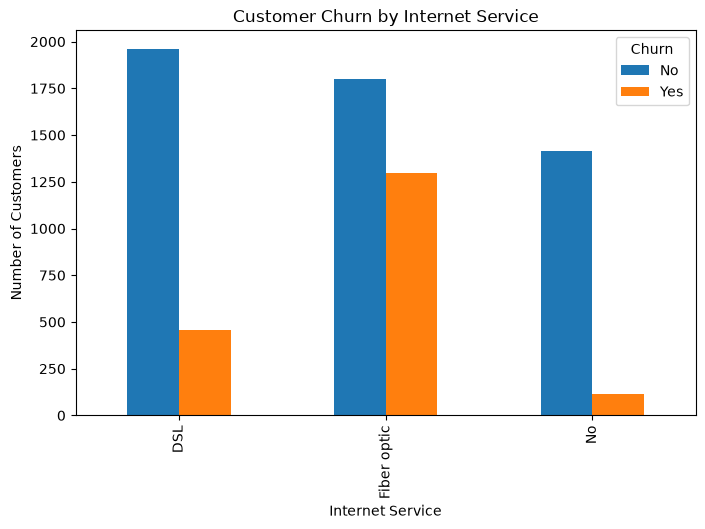

In [10]:
internet_churn = pd.crosstab(df["InternetService"], df["Churn"])

internet_churn.plot(kind="bar", figsize=(8,5))

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.savefig("../images/churn_by_internet_service.png", dpi=300, bbox_inches="tight")
plt.show()

## Business Insight

Customers using fiber optic internet often exhibit higher churn rates than customers using DSL or having no internet service.

This may indicate issues related to pricing, service quality, or customer expectations.

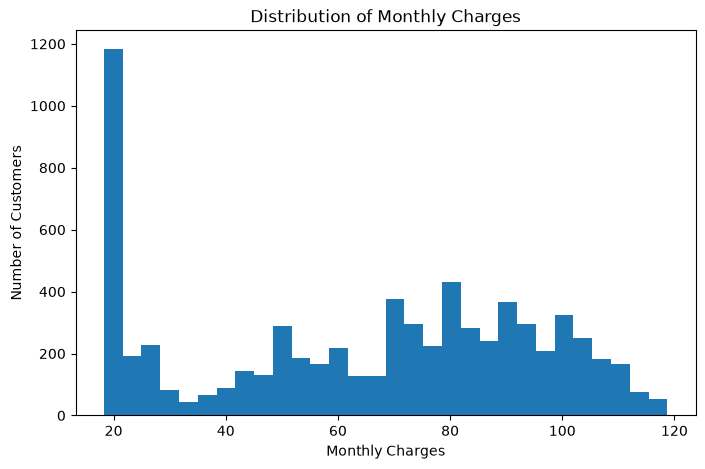

In [11]:
plt.figure(figsize=(8,5))

plt.hist(df["MonthlyCharges"], bins=30)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.savefig("../images/monthly_charges_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Business Insight

This distribution helps identify whether customers are concentrated in low, medium, or high monthly charge ranges.

Further analysis will determine whether customers paying higher monthly charges are more likely to churn.

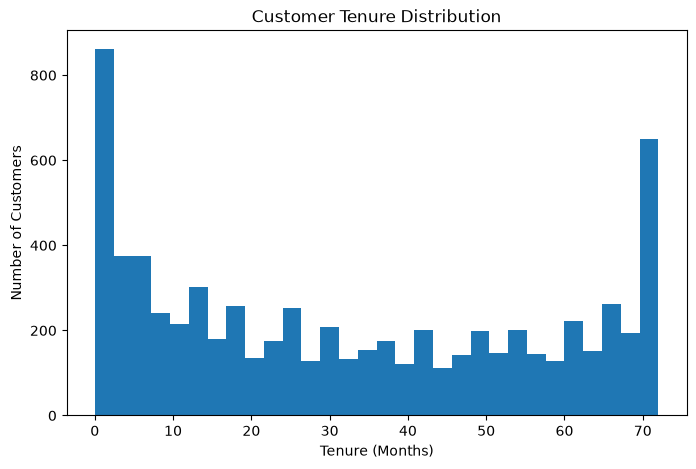

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df["tenure"], bins=30)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.savefig("../images/customer_tenure_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Business Insight

Customer tenure shows how long customers remain with the company.

Customers with shorter tenures generally have a higher risk of churn, highlighting the importance of improving the onboarding experience.

In [13]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Calculate correlation matrix
correlation = numeric_df.corr()

print(correlation)

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.016567        0.220173      0.102652
tenure               0.016567  1.000000        0.247900      0.825464
MonthlyCharges       0.220173  0.247900        1.000000      0.650864
TotalCharges         0.102652  0.825464        0.650864      1.000000


## Business Insight

The correlation matrix helps identify relationships between numerical variables.

Strong correlations can indicate useful features for machine learning and help understand customer behavior.

In [14]:
revenue_loss = df[df["Churn"] == "Yes"]["MonthlyCharges"].sum()

print(f"Estimated Monthly Revenue Lost: ${revenue_loss:.2f}")

Estimated Monthly Revenue Lost: $139130.85


## Business Insight

Revenue lost from churned customers highlights the financial impact of customer attrition.

Reducing churn even by a small percentage can significantly improve company revenue.

In [15]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

# Executive Summary

## Key Findings

- Approximately 26% of customers have churned.
- Month-to-month contract customers have the highest churn.
- Customers using Electronic Check show higher churn.
- Fiber Optic customers churn more frequently.
- Customers with short tenure are at greater risk.
- Higher monthly charges are associated with increased churn.

## Business Recommendations

1. Promote long-term contracts through discounts.
2. Encourage automatic payment methods.
3. Improve onboarding for new customers.
4. Offer retention incentives to high-risk customers.
5. Monitor high monthly charge customers proactively.